# Feature Value Attribution Analysis

This notebook analyzes which specific feature VALUES receive high attributions:

1. **Top Feature Values**: Which values (e.g., "Activity=Resolve ticket") get highest mean absolute attribution?
2. **Top Value Combinations**: Which pairs of categorical values co-occur with high attribution?

## 1. Setup

In [1]:
# Path setup and config import
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

from src.interpretability.config.helpdesk_config import CONFIG
print(f"Dataset: {CONFIG.dataset_name}")

Dataset: Helpdesk


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import defaultdict
import pickle
import random
from itertools import combinations

from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Reproducibility
SEED = CONFIG.seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

tool = InterpretabilityTool(model, model.data_set_categories, device=device)

print(f"Loaded {len(test_dataset)} samples")
print(f"Available cases: {len(eval_helper.cases)}")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

## 2. Configuration

In [4]:
# ============================================================
# CONFIGURATION
# ============================================================
TEST_MODE = True          # Set to False for full dataset analysis
TEST_SAMPLE_SIZE = 300    # Number of samples in test mode
IG_STEPS = 30             # Integration steps
TARGET = CONFIG.concept_name

# Get feature names from model
cat_categories, num_categories = model.data_set_categories
ALL_CAT_FEATURES = [name for name, _, _ in cat_categories]
ALL_NUM_FEATURES = [name for name, _, _ in num_categories]

# Build index-to-value mappings
idx_to_value_maps = {}
for feat_name, num_values, value_mapping in cat_categories:
    idx_to_value_maps[feat_name] = {v: k for k, v in value_mapping.items()}

print(f"Mode: {'TEST' if TEST_MODE else 'FULL'}")
print(f"Categorical features: {ALL_CAT_FEATURES}")
print(f"Numerical features: {ALL_NUM_FEATURES}")

Mode: TEST
Categorical features: ['Activity', 'Resource', 'Variant index', 'seriousness', 'customer', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup']
Numerical features: ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day']


## 3. Prepare Samples

In [5]:
# Collect all prefix-suffix pairs
all_samples = []

for case_name, full_case in tqdm(eval_helper.cases.items(), desc="Collecting samples"):
    for prefix_len, prefix, suffix in eval_helper._iterate_case(full_case):
        if prefix_len >= 1:
            all_samples.append({
                'case_name': case_name,
                'prefix_len': prefix_len,
                'prefix': prefix,
                'suffix': suffix
            })

print(f"Total samples: {len(all_samples)}")

if TEST_MODE:
    samples = random.sample(all_samples, min(TEST_SAMPLE_SIZE, len(all_samples)))
    print(f"Using {len(samples)} samples (test mode)")
else:
    samples = all_samples
    print(f"Using all {len(samples)} samples (full mode)")

Total samples: 3329
Using 300 samples (test mode)


## 4. Top Feature Values by Mean Absolute Attribution

Which specific feature VALUES receive the highest mean absolute attribution?

In [6]:
# Compute attribution for each feature-value
feature_value_attribution = defaultdict(float)
feature_value_counts = defaultdict(int)

# Also track per-sample combinations for the next section
sample_value_attributions = []  # List of dicts with {feat: {value: attr}} per sample

for sample in tqdm(samples, desc="Computing attributions"):
    try:
        prefix = sample['prefix']
        prefix_len = sample['prefix_len']
        
        cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
        num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
        process = (cat_tensors, num_tensors)
        
        attr_map = tool.compute_attribution_map(
            process=process,
            prefix_length=prefix_len,
            target=TARGET,
            target_class='auto',
            method='integrated_gradients',
            n_steps=IG_STEPS
        )
        
        # Track attributions for this sample (for combination analysis)
        sample_attrs = {}
        
        for feat_idx, feat_name in enumerate(ALL_CAT_FEATURES):
            if feat_name in attr_map.attributions and feat_idx < len(cat_tensors):
                vals = attr_map.attributions[feat_name]
                if hasattr(vals, 'detach'):
                    vals = vals.detach().cpu().numpy()
                
                feat_tensor = cat_tensors[feat_idx]
                seq_len = len(feat_tensor)
                start_pos = max(0, seq_len - prefix_len)
                
                sample_attrs[feat_name] = {}
                
                for t in range(start_pos, seq_len):
                    value_idx = feat_tensor[t].item()
                    if value_idx == 0:
                        continue
                    
                    value_name = idx_to_value_maps.get(feat_name, {}).get(value_idx, None)
                    if value_name is None:
                        continue
                    
                    if hasattr(vals, '__len__') and t < len(vals):
                        attr_val = np.abs(vals[t])
                    else:
                        attr_val = np.abs(vals).sum() / prefix_len
                    
                    key = f"{feat_name}={value_name}"
                    feature_value_attribution[key] += attr_val
                    feature_value_counts[key] += 1
                    
                    # Track for combination analysis
                    if value_name not in sample_attrs[feat_name]:
                        sample_attrs[feat_name][value_name] = 0
                    sample_attrs[feat_name][value_name] += attr_val
        
        # For numerical features
        for feat_idx, feat_name in enumerate(ALL_NUM_FEATURES):
            if feat_name in attr_map.attributions and feat_idx < len(num_tensors):
                vals = attr_map.attributions[feat_name]
                if hasattr(vals, 'detach'):
                    vals = vals.detach().cpu().numpy()
                
                key = f"{feat_name} (numerical)"
                feature_value_attribution[key] += np.abs(vals).sum()
                feature_value_counts[key] += 1
        
        sample_value_attributions.append(sample_attrs)
                
    except Exception as e:
        sample_value_attributions.append({})  # Empty for failed samples

print(f"\nTracked {len(feature_value_attribution)} unique feature-value pairs")

Computing attributions:   0%|          | 0/300 [00:00<?, ?it/s]


Tracked 243 unique feature-value pairs


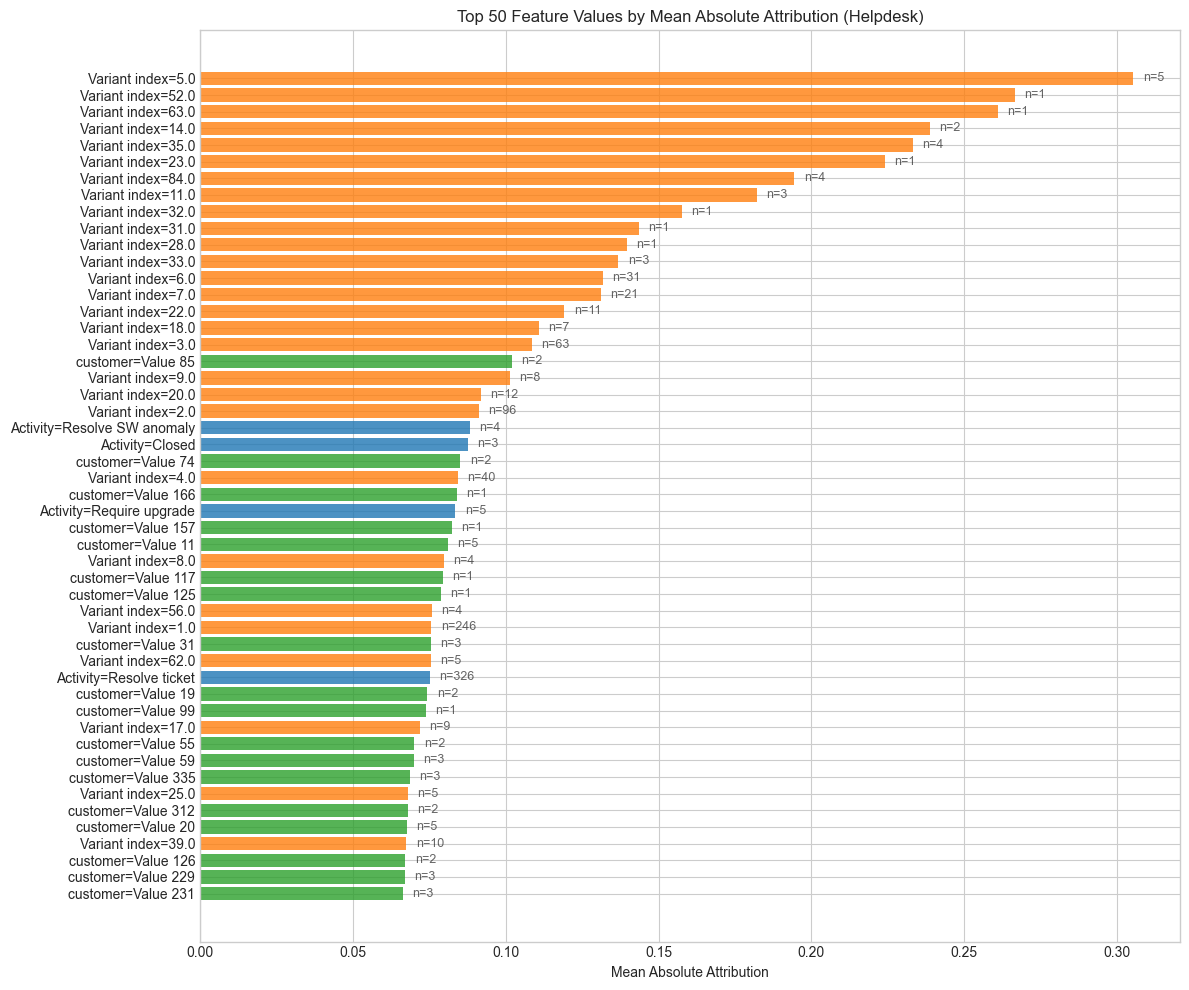


Top 50 Feature Values by Mean Absolute Attribution:
Rank  Feature=Value                                  Mean Abs Attr    Count
--------------------------------------------------------------------------------
1     Variant index=5.0                                   0.305313        5
2     Variant index=52.0                                  0.266474        1
3     Variant index=63.0                                  0.261053        1
4     Variant index=14.0                                  0.238814        2
5     Variant index=35.0                                  0.233309        4
6     Variant index=23.0                                  0.223963        1
7     Variant index=84.0                                  0.194425        4
8     Variant index=11.0                                  0.182207        3
9     Variant index=32.0                                  0.157622        1
10    Variant index=31.0                                  0.143614        1
11    Variant index=28.0      

In [7]:
# Create bar chart of top 20 feature-value pairs by MEAN ABSOLUTE attribution
TOP_N = 50

# Compute mean absolute attribution
feature_value_avg = {
    k: v / feature_value_counts[k] if feature_value_counts[k] > 0 else 0
    for k, v in feature_value_attribution.items()
}

sorted_fv = sorted(feature_value_avg.items(), key=lambda x: x[1], reverse=True)
top_fv = sorted_fv[:TOP_N]

labels = [fv[0] for fv in top_fv]
avg_values = [fv[1] for fv in top_fv]
counts = [feature_value_counts[fv[0]] for fv in top_fv]

labels_display = [l[:40] + "..." if len(l) > 40 else l for l in labels]

fig, ax = plt.subplots(figsize=(12, 10))

colors = []
for label in labels:
    feat_name = label.split('=')[0].replace(' (numerical)', '')
    if feat_name in ALL_CAT_FEATURES:
        feat_idx = ALL_CAT_FEATURES.index(feat_name)
        colors.append(plt.cm.tab20(feat_idx % 20))
    else:
        feat_idx = ALL_NUM_FEATURES.index(feat_name) if feat_name in ALL_NUM_FEATURES else 0
        colors.append(plt.cm.tab20(12 + feat_idx % 8))

bars = ax.barh(range(len(labels_display)), avg_values, color=colors, alpha=0.8)
ax.set_yticks(range(len(labels_display)))
ax.set_yticklabels(labels_display)
ax.invert_yaxis()
ax.set_xlabel('Mean Absolute Attribution')
ax.set_title(f'Top {TOP_N} Feature Values by Mean Absolute Attribution ({CONFIG.dataset_name})')

for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(bar.get_width() + max(avg_values)*0.01, bar.get_y() + bar.get_height()/2, 
            f'n={count}', va='center', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

print(f"\nTop {TOP_N} Feature Values by Mean Absolute Attribution:")
print("="*80)
print(f"{'Rank':<5} {'Feature=Value':<45} {'Mean Abs Attr':>14} {'Count':>8}")
print("-"*80)
for i, (label, mean_attr) in enumerate(top_fv, 1):
    count = feature_value_counts[label]
    print(f"{i:<5} {label[:45]:<45} {mean_attr:>14.6f} {count:>8}")

## 5. Top Value Combinations by Mean Absolute Attribution

Which pairs of categorical values co-occur with high combined attribution?

For each sample, we look at all pairs of (Feature1=Value1, Feature2=Value2) and sum their attributions.

In [8]:
# Compute attribution for value combinations (pairs)
combo_attribution = defaultdict(float)
combo_counts = defaultdict(int)

for sample_attrs in tqdm(sample_value_attributions, desc="Computing combinations"):
    if not sample_attrs:
        continue
    
    # Get all (feature, value, attribution) tuples from this sample
    fv_attrs = []
    for feat_name, value_dict in sample_attrs.items():
        for value_name, attr in value_dict.items():
            fv_attrs.append((feat_name, value_name, attr))
    
    # Generate all pairs of different features
    for i in range(len(fv_attrs)):
        for j in range(i + 1, len(fv_attrs)):
            feat1, val1, attr1 = fv_attrs[i]
            feat2, val2, attr2 = fv_attrs[j]
            
            # Only consider pairs from DIFFERENT features
            if feat1 == feat2:
                continue
            
            # Create canonical key (sorted to avoid duplicates)
            key1 = f"{feat1}={val1}"
            key2 = f"{feat2}={val2}"
            combo_key = tuple(sorted([key1, key2]))
            
            # Combined attribution = sum of both
            combined_attr = attr1 + attr2
            
            combo_attribution[combo_key] += combined_attr
            combo_counts[combo_key] += 1

print(f"\nTracked {len(combo_attribution)} unique value combinations")

Computing combinations:   0%|          | 0/300 [00:00<?, ?it/s]


Tracked 3497 unique value combinations


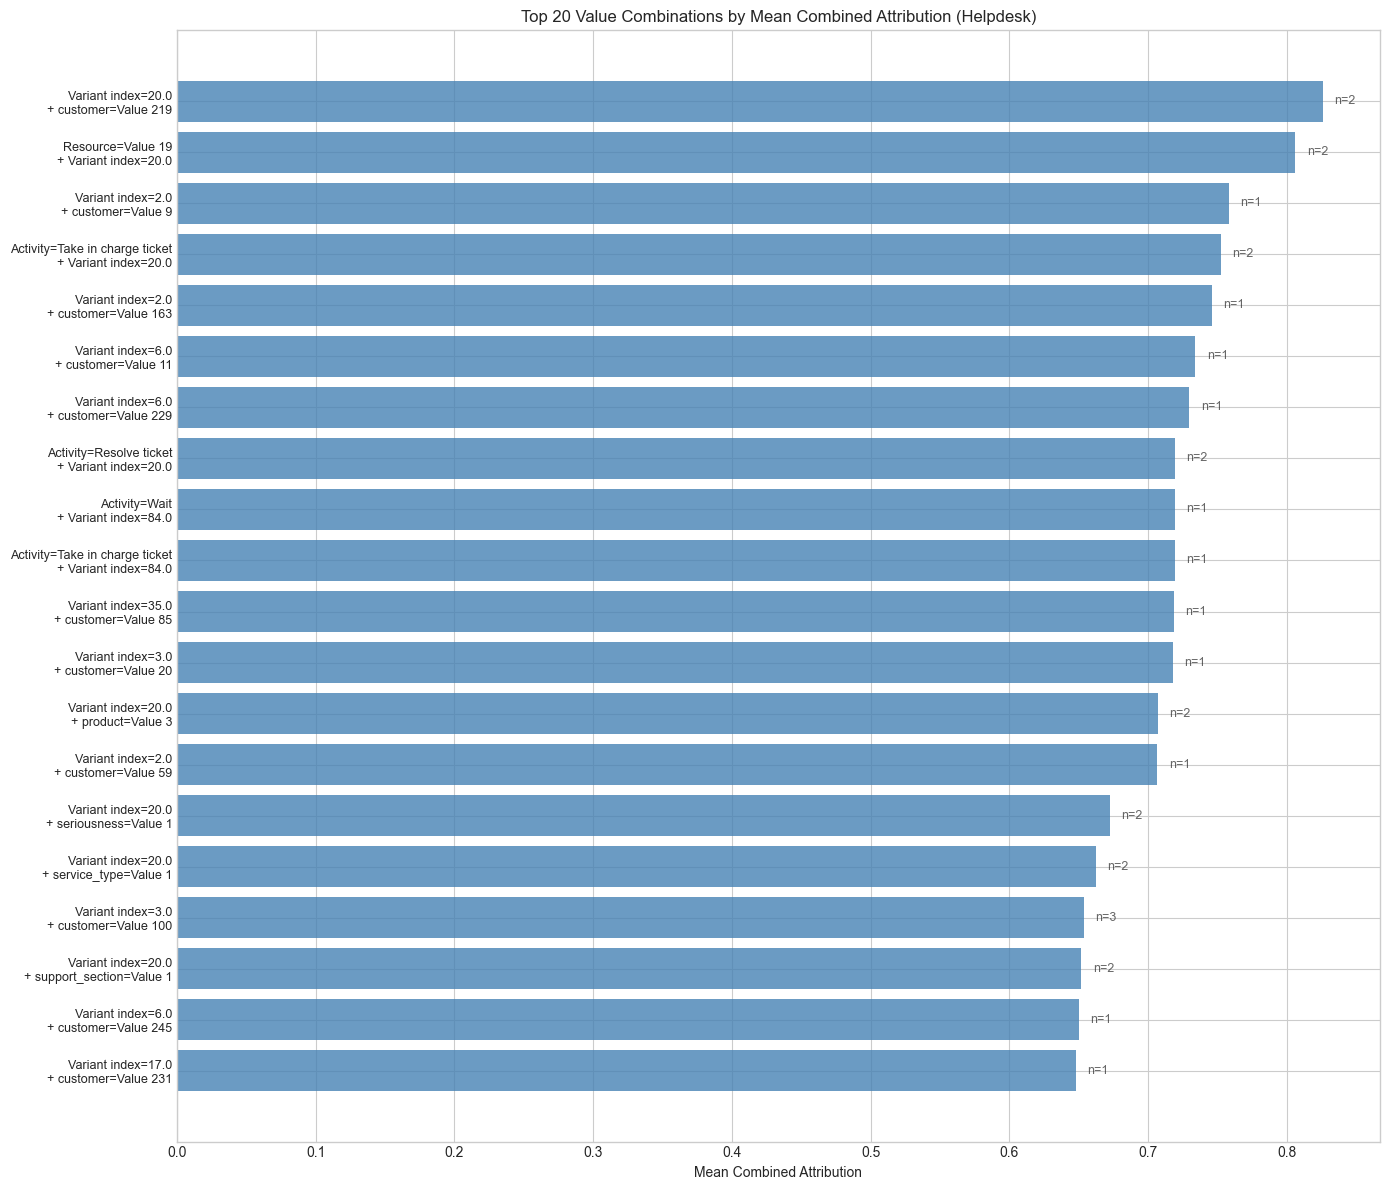


Top 20 Value Combinations by Mean Combined Attribution:
Rank  Value 1                                                 Value 2                                                    Mean Attr    Count
----------------------------------------------------------------------------------------------------------------------------------
1     Variant index=20.0                                      customer=Value 219                                          0.825807        2
2     Resource=Value 19                                       Variant index=20.0                                          0.806177        2
3     Variant index=2.0                                       customer=Value 9                                            0.758328        1
4     Activity=Take in charge ticket                          Variant index=20.0                                          0.752183        2
5     Variant index=2.0                                       customer=Value 163                                

In [9]:
# Create bar chart of top 20 combinations by MEAN combined attribution
TOP_N_COMBOS = 20

# Compute mean combined attribution
combo_avg = {
    k: v / combo_counts[k] if combo_counts[k] > 0 else 0
    for k, v in combo_attribution.items()
}

sorted_combos = sorted(combo_avg.items(), key=lambda x: x[1], reverse=True)
top_combos = sorted_combos[:TOP_N_COMBOS]

# Prepare data
combo_labels = [f"{c[0][0]}\n+ {c[0][1]}" for c in top_combos]
combo_values = [c[1] for c in top_combos]
combo_ns = [combo_counts[c[0]] for c in top_combos]

# Truncate labels for plot only
combo_labels_short = []
for c in top_combos:
    l1 = c[0][0][:35] + "..." if len(c[0][0]) > 35 else c[0][0]
    l2 = c[0][1][:35] + "..." if len(c[0][1]) > 35 else c[0][1]
    combo_labels_short.append(f"{l1}\n+ {l2}")

fig, ax = plt.subplots(figsize=(14, 12))

bars = ax.barh(range(len(combo_labels_short)), combo_values, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(combo_labels_short)))
ax.set_yticklabels(combo_labels_short, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Mean Combined Attribution')
ax.set_title(f'Top {TOP_N_COMBOS} Value Combinations by Mean Combined Attribution ({CONFIG.dataset_name})')

for i, (bar, n) in enumerate(zip(bars, combo_ns)):
    ax.text(bar.get_width() + max(combo_values)*0.01, bar.get_y() + bar.get_height()/2, 
            f'n={n}', va='center', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

# Print table with wider columns
print(f"\nTop {TOP_N_COMBOS} Value Combinations by Mean Combined Attribution:")
print("="*130)
print(f"{'Rank':<5} {'Value 1':<55} {'Value 2':<55} {'Mean Attr':>12} {'Count':>8}")
print("-"*130)
for i, (combo_key, mean_attr) in enumerate(top_combos, 1):
    v1, v2 = combo_key
    count = combo_counts[combo_key]
    print(f"{i:<5} {v1:<55} {v2:<55} {mean_attr:>12.6f} {count:>8}")

## 6. Combination Heatmap

Heatmap showing mean attribution for combinations of top values from different features.

Creating heatmap for: Activity vs Variant index


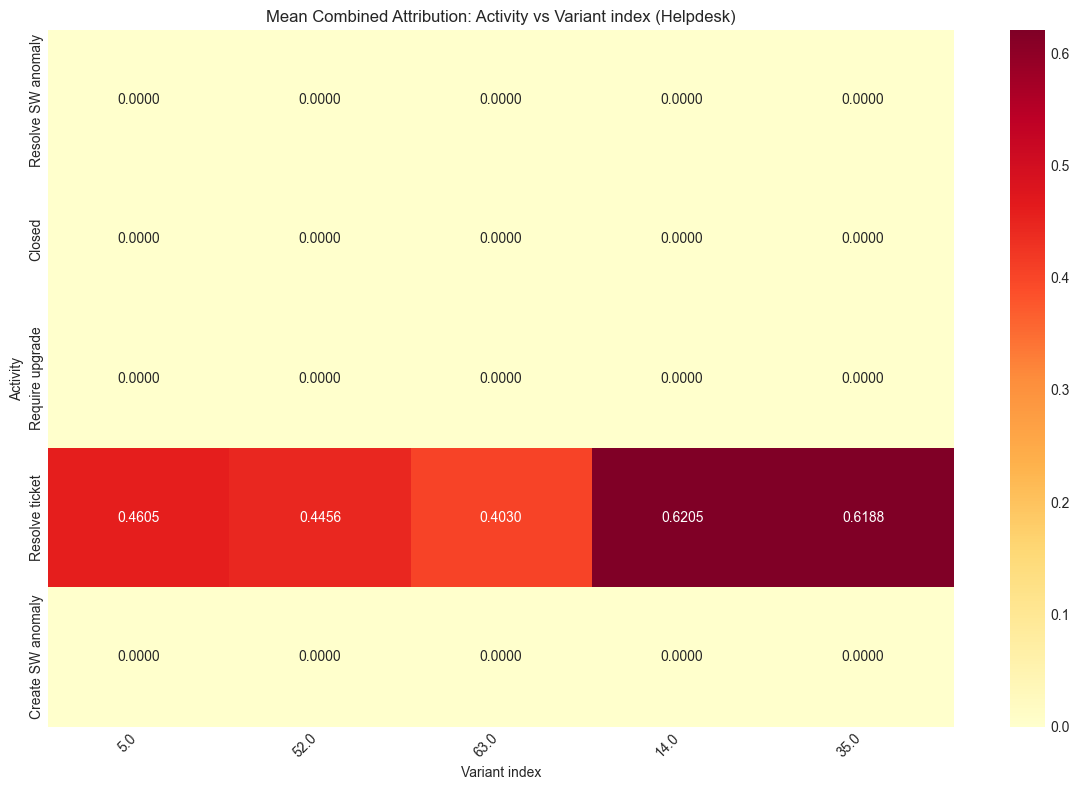

In [10]:
# Get top 5 values per feature (by mean attribution)
top_values_per_feature = {}
for feat_name in ALL_CAT_FEATURES:
    feat_values = {k: v for k, v in feature_value_avg.items() if k.startswith(f"{feat_name}=")}
    sorted_vals = sorted(feat_values.items(), key=lambda x: x[1], reverse=True)[:5]
    top_values_per_feature[feat_name] = [v[0] for v in sorted_vals]

# Create heatmap for combinations between two specific features
# Use Activity and the second most important categorical feature
feat1 = 'Activity'
# Find second most important feature by total attribution
feat_totals = defaultdict(float)
for k, v in feature_value_avg.items():
    feat_name = k.split('=')[0]
    if feat_name in ALL_CAT_FEATURES:
        feat_totals[feat_name] += v

sorted_feats = sorted(feat_totals.items(), key=lambda x: x[1], reverse=True)
feat2 = sorted_feats[1][0] if len(sorted_feats) > 1 else sorted_feats[0][0]

print(f"Creating heatmap for: {feat1} vs {feat2}")

# Get top values for these features
vals1 = top_values_per_feature.get(feat1, [])[:8]
vals2 = top_values_per_feature.get(feat2, [])[:8]

if vals1 and vals2:
    # Build heatmap matrix
    heatmap_data = np.zeros((len(vals1), len(vals2)))
    
    for i, v1 in enumerate(vals1):
        for j, v2 in enumerate(vals2):
            combo_key = tuple(sorted([v1, v2]))
            if combo_key in combo_avg:
                heatmap_data[i, j] = combo_avg[combo_key]
    
    # Clean up labels
    labels1 = [v.split('=')[1][:20] for v in vals1]
    labels2 = [v.split('=')[1][:20] for v in vals2]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd',
                xticklabels=labels2, yticklabels=labels1, ax=ax)
    ax.set_xlabel(feat2)
    ax.set_ylabel(feat1)
    ax.set_title(f'Mean Combined Attribution: {feat1} vs {feat2} ({CONFIG.dataset_name})')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough values to create heatmap")

## 7. Save Results

In [11]:
# Save results
output_dir = CONFIG.get_results_dir()
mode_suffix = '_test' if TEST_MODE else '_full'

results = {
    'feature_value_attribution': dict(feature_value_attribution),
    'feature_value_counts': dict(feature_value_counts),
    'feature_value_avg': feature_value_avg,
    'combo_attribution': {str(k): v for k, v in combo_attribution.items()},
    'combo_counts': {str(k): v for k, v in combo_counts.items()},
    'combo_avg': {str(k): v for k, v in combo_avg.items()},
    'config': CONFIG.to_dict(),
    'test_mode': TEST_MODE
}

output_path = output_dir / f'feature_value_attribution{mode_suffix}.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(results, f)

print(f"Results saved to: {output_path}")

Results saved to: /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/interpretability/notebooks/results/helpdesk/feature_value_attribution_test.pkl


## 8. Summary

In [12]:
print("="*80)
print(f"FEATURE VALUE ATTRIBUTION SUMMARY")
print("="*80)
print(f"\nDataset: {CONFIG.dataset_name}")
print(f"Mode: {'TEST' if TEST_MODE else 'FULL'}")
print(f"Samples analyzed: {len(samples)}")

print(f"\n--- Top 10 Feature Values ---")
for i, (label, mean_attr) in enumerate(sorted_fv[:10], 1):
    count = feature_value_counts[label]
    print(f"{i:>2}. {label}: {mean_attr:.6f} (n={count})")

print(f"\n--- Top 10 Value Combinations ---")
for i, (combo_key, mean_attr) in enumerate(sorted_combos[:10], 1):
    v1, v2 = combo_key
    count = combo_counts[combo_key]
    print(f"{i:>2}. {v1} + {v2}")
    print(f"    Mean attr: {mean_attr:.6f} (n={count})")

FEATURE VALUE ATTRIBUTION SUMMARY

Dataset: Helpdesk
Mode: TEST
Samples analyzed: 300

--- Top 10 Feature Values ---
 1. Variant index=5.0: 0.305313 (n=5)
 2. Variant index=52.0: 0.266474 (n=1)
 3. Variant index=63.0: 0.261053 (n=1)
 4. Variant index=14.0: 0.238814 (n=2)
 5. Variant index=35.0: 0.233309 (n=4)
 6. Variant index=23.0: 0.223963 (n=1)
 7. Variant index=84.0: 0.194425 (n=4)
 8. Variant index=11.0: 0.182207 (n=3)
 9. Variant index=32.0: 0.157622 (n=1)
10. Variant index=31.0: 0.143614 (n=1)

--- Top 10 Value Combinations ---
 1. Variant index=20.0 + customer=Value 219
    Mean attr: 0.825807 (n=2)
 2. Resource=Value 19 + Variant index=20.0
    Mean attr: 0.806177 (n=2)
 3. Variant index=2.0 + customer=Value 9
    Mean attr: 0.758328 (n=1)
 4. Activity=Take in charge ticket + Variant index=20.0
    Mean attr: 0.752183 (n=2)
 5. Variant index=2.0 + customer=Value 163
    Mean attr: 0.745993 (n=1)
 6. Variant index=6.0 + customer=Value 11
    Mean attr: 0.734070 (n=1)
 7. Varian